# 서울시 119 구급 관련 공공 API

**실시간/최신 공공데이터 API 호출 코드**


## 0. 환경 설정 및 API 오류 예외처리

In [1]:
import os
import time
import requests
import pandas as pd
import xml.etree.ElementTree as ET
from dotenv import load_dotenv

load_dotenv()
SERVICE_KEY = os.getenv("DATA_GO_KR_KEY")

# 원본 데이터 폴더
SRC_DIR = "C:/ai/source/09_Project/data"
OUT_DIR = "C:/ai/source/09_Project/data/outputs"
os.makedirs(OUT_DIR, exist_ok=True)


In [2]:
class RateLimitExhausted(Exception):
    "사용량 소진 시 예외 호출"
    pass


def request_get_with_retry(url, params, max_retries=5, base_delay=2.0, timeout=10):
    """
    - 429 : 대기 후 재시도
    - 5xx : 서버 일시 오류로 보고 동일하게 재시도
    - 그 외 4xx : 재시도해도 소용없으므로 즉시 예외 발생

    """
    last_status = None
    
    for attempt in range(max_retries):
        response = requests.get(url, params=params, timeout=timeout)
        
        if response.status_code == 200:
            return response
        last_status = response.status_code
        
        if response.status_code == 429 or 500 <= response.status_code < 600:
            wait = float(response.headers.get("Retry-After", base_delay * (2 ** attempt)))
            print(f"  [재시도 {attempt+1}/{max_retries}] 오류 코드 {response.status_code} -> {wait:.1f}초 대기")
            time.sleep(wait)
            continue
        response.raise_for_status()  # 429/5xx가 아닌 다른 오류는 바로 예외

    if last_status == 429:
        raise RateLimitExhausted("당일 트래픽(일일 쿼터)을 모두 소진했습니다.")
    resp.raise_for_status()
    
    return response


# 429 에러코드 발생 시 점차 증가시킬 것
REQUEST_INTERVAL = 1.0


### 0-1. 소방서 → 자치구 매핑 준비

In [3]:
import re

station_df = pd.read_csv(f"{SRC_DIR}/서울소방서 119안전센터 현황.csv", encoding="cp949")

def extract_gu(text):
    if pd.isna(text):
        return None
    m = re.search(r'([가-힣]+구)', str(text))
    return m.group(1) if m else None

station_df['District_guess'] = station_df['관할구역'].apply(extract_gu)
STATION2GU = station_df.groupby('서별')['District_guess'] \
    .agg(lambda x: x.value_counts().index[0]).to_dict()

VALID_GU = {'종로구','중구','용산구','성동구','광진구','동대문구','중랑구','성북구','강북구','도봉구',
            '노원구','은평구','서대문구','마포구','양천구','강서구','구로구','금천구','영등포구',
            '동작구','관악구','서초구','강남구','송파구','강동구'}
SEOUL_GU_LIST = sorted(VALID_GU)

print(f"소방서 매핑 {len(STATION2GU)}개, 자치구 {len(VALID_GU)}개")


소방서 매핑 25개, 자치구 25개


---
## 1. 소방청 구급통계 서비스 (EmergencyStatisticsService)

In [4]:
FIRE_BASE_URL = "http://apis.data.go.kr/1661000/EmergencyStatisticsService/get119EmgencyActivityStats"

def fetch_119_activity(sido_hq="서울소방재난본부", station=None, ym=None, num_of_rows=100, page_no=1):
    """소방청 구급통계 - 119구급활동현황 호출"""
    params = {
        "serviceKey": SERVICE_KEY,
        "pageNo": page_no,
        "numOfRows": num_of_rows,
        "resultType": "xml",
        "sidoHqOgidNm": sido_hq,
    }
    
    if station:
        params["rsacGutFsttOgidNm"] = station
    if ym:
        params["rcptYm"] = ym  # 'YYYYMM' 형식

    response = request_get_with_retry(FIRE_BASE_URL, params)

    root = ET.fromstring(response.text)
    result_code = root.findtext(".//resultCode")
    if result_code != "00":
        raise RuntimeError("API 오류")

    rows = []
    for item in root.findall(".//item"):
        rows.append({child.tag: child.text for child in item})
    
    return pd.DataFrame(rows), int(root.findtext(".//totalCount", default=0))


def fetch_119_activity_all(sido_hq="서울소방재난본부", station=None, ym=None):
    """totalCount 만큼 페이징하며 전체 수집"""
    
    all_rows = []
    page = 1
    
    while True:
        df, total = fetch_119_activity(sido_hq, station, ym, num_of_rows=100, page_no=page)
        
        if df.empty:
            break
        all_rows.append(df)
        
        if page * 100 >= total:
            break
            
        page += 1
        time.sleep(REQUEST_INTERVAL)
        
    return pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()

### 1-1. 25개 자치구(소방서) 전체 최신 월 수집

In [5]:
def collect_latest_month_all_gu(ym):
    """지정한 접수년월(YYYYMM)에 대해 25개 소방서 전체 데이터 수집"""
    
    records = []
    
    for station, gu in STATION2GU.items():
        try:
            df = fetch_119_activity_all(sido_hq="서울소방재난본부", station=station, ym=ym)
        except Exception as e:
            print(f"{station} 수집 실패 : {e}")
            time.sleep(REQUEST_INTERVAL)
            continue
            
        if df.empty:
            time.sleep(REQUEST_INTERVAL)
            continue
            
        row = df.iloc[0]
        records.append({
            "ds": f"{ym[:4]}-{ym[4:6]}-01",
            "District": gu,
            "y": float(row.get("gutCo", 0)),
            "transport_cnt": float(row.get("trnfCo", 0)),
            "transport_person": float(row.get("trnfPcnt", 0)),
        })
        time.sleep(REQUEST_INTERVAL)
        
    return pd.DataFrame(records)

In [6]:
def collect_month_range_all_gu(start_ym, end_ym, combined_path=None, resume=True):
    if combined_path is None:
        combined_path = f"{OUT_DIR}/ambulance_prophet_{start_ym}_{end_ym}_api.csv"

    months = pd.period_range(
        start=pd.Period(start_ym, freq="M"),
        end=pd.Period(end_ym, freq="M"), 
        freq="M"
        )
    months = [m.strftime("%Y%m") for m in months]

    already = pd.DataFrame()
    done_months = set()
    if resume and os.path.exists(combined_path):
        already = pd.read_csv(combined_path)
        done_months = set(pd.to_datetime(already["ds"]).dt.strftime("%Y%m"))
        print(f"{combined_path}에 이미 {len(done_months)}개월치 데이터가 있어 건너뜀 : {sorted(done_months)}")

    all_frames = [already] if not already.empty else []
    quota_exhausted = False
    for ym in months:
        if ym in done_months:
            continue
            
        print(f"=== {ym} 수집 중 ({months.index(ym)+1}/{len(months)}) ===")
        
        try:
            month_df = collect_latest_month_all_gu(ym)
            
        except RateLimitExhausted as e:
            print(f"\n일일 쿼터 소진 : {e}")
            print("쿼터 리셋 후 해당 셀 재실행 시 이어받습니다.")
            quota_exhausted = True
            break
        if month_df.empty:
            print(f"  -> {ym}: 데이터 없음(집계 전으로 추정), 건너뜀")
            continue
        all_frames.append(month_df)

        # 중간 저장 ; 매달 끝날 때마다 지금까지 결과를 저장해서, 도중에 실패해도 이어받을 수 있게 함
        combined_so_far = pd.concat(all_frames, ignore_index=True).drop_duplicates(subset=["ds", "District"])
        combined_so_far.to_csv(combined_path, index=False, encoding="utf-8")
        print(f"  -> {ym}: {len(month_df)}행 수집, 누적 저장 완료 ({combined_path})")

    if not all_frames:
        if not quota_exhausted:
            print("[경고] 수집된 데이터가 전혀 없습니다.")
        return pd.DataFrame()

    result = pd.concat(all_frames, ignore_index=True).drop_duplicates(subset=["ds", "District"]) \
                .sort_values(["District", "ds"]).reset_index(drop=True)
    return result

In [7]:
def _probe_month_has_data(ym, probe_station="구로소방서"):
    """단일 소방서 1건만 조회해서 요청한 해당 월에 데이터가 있는지 빠르게 확인"""
    
    try:
        probe_df, _ = fetch_119_activity(
            sido_hq="서울소방재난본부", 
            station=probe_station,
            ym=ym, 
            num_of_rows=1, 
            page_no=1)
    except RateLimitExhausted:
        raise
    except Exception as e:
        print(f"  {ym} 데이터 수집 실패: {e}")
        return False
    
    return not probe_df.empty


def find_latest_available_month(max_back=36, probe_station="구로소방서"):
    """오늘 기준 전월부터 거슬러 올라가며 데이터가 있는 가장 최근 월을 탐색"""
    
    start_ym = pd.Timestamp.now().replace(day=1) - pd.Timedelta(days=1)
    
    for back in range(max_back):
        try_ym = (start_ym.replace(day=1) - pd.DateOffset(months=back)).strftime("%Y%m")
        if _probe_month_has_data(try_ym, probe_station):
            return try_ym
        time.sleep(REQUEST_INTERVAL)
        
    return None


def find_earliest_available_month(search_from="201001", max_forward=240, probe_station="구로소방서"):
    """search_from부터 앞으로 나아가며 데이터가 있는 가장 이른 월을 탐색"""
    
    ym = pd.Period(search_from, freq="M")
    
    for _ in range(max_forward):
        try_ym = ym.strftime("%Y%m")
        if _probe_month_has_data(try_ym, probe_station):
            return try_ym
        ym += 1
        time.sleep(REQUEST_INTERVAL)
        
    return None

---
## 2. 국립중앙의료원 응급의료기관 정보 조회 서비스

In [8]:
NIA_BASE_URL = "http://apis.data.go.kr/B552657/ErmctInfoInqireService"

def _parse_items_generic(xml_text):
    """XML 형태의 API 응답 결과를 파이썬 딕셔너리 리스트로 변환"""
    root = ET.fromstring(xml_text)
    result_code = root.findtext(".//resultCode")
    
    if result_code not in (None, "00"):
        raise RuntimeError(f"API 오류: {result_code} / {root.findtext('.//resultMsg')}")
        
    rows = [{child.tag: child.text for child in item} for item in root.findall(".//item")]
    total = int(root.findtext(".//totalCount", default=0) or 0)
    
    return rows, total


def fetch_egyt_bass_info(sido, sigungu=None, num_of_rows=100, page_no=1):
    """응급의료기관 기본정보 조회"""
    
    params = {
        "serviceKey": SERVICE_KEY, 
        "pageNo": page_no, 
        "numOfRows": num_of_rows, 
        "Q0": sido
    }
    
    if sigungu:
        params["Q1"] = sigungu
        
    response = request_get_with_retry(f"{NIA_BASE_URL}/getEgytBassInfoInqire", params)
    rows, total = _parse_items_generic(response.text)
    
    return pd.DataFrame(rows), total


# 응급실(hvec)과 연관이 있는 필드만 추출할 때 사용할 컬럼 매핑
ER_FIELD_MAP = {
    "hpid": "Hospital_ID",
    "dutyName": "Hospital_Name",
    "dutyTel3": "Tel",
    "hvidate": "Updated_At",
    "hvec": "Available_Beds",
    "hvamyn": "Ambulance_Available",
}

def fetch_realtime_er_beds(sido, sigungu=None, num_of_rows=100, page_no=1):
    """
    실시간 응급실 가용병상정보 조회에서
    응급실과 연관이 있는 필드만 뽑아서 반환
    """
    params = {
        "serviceKey": SERVICE_KEY,
        "STAGE1": sido,   
        "STAGE2": sigungu,   
        "pageNo": page_no,
        "numOfRows": num_of_rows,
    }
    response = request_get_with_retry(f"{NIA_BASE_URL}/getEmrrmRltmUsefulSckbdInfoInqire", params)
    rows, total = _parse_items_generic(response.text)

    cleaned = []
    for row in rows:
        item = {new_col: row.get(old_col) for old_col, new_col in ER_FIELD_MAP.items()}
        try:
            beds = int(item["Available_Beds"])
        except (TypeError, ValueError):
            beds = None

        if beds is not None and beds < 0:
            # 음수 : '정보 없음/미보고' ; 실제 병상 수가 아니므로 결측 처리
            item["Beds_Unknown"] = True
            item["Available_Beds"] = None
        else:
            item["Beds_Unknown"] = beds is None
            item["Available_Beds"] = beds
        cleaned.append(item)

    return pd.DataFrame(cleaned), total

### 2-1 25개 자치구 전체 순회 + Forward Fill 처리

In [9]:
def collect_realtime_beds_all_gu(prev_file=None):
    """
    25개 자치구를 순회하며 응급실 가용병상만 수집
    prev_file이 존재하면, 이번 호출이 실패/빈 응답인 구는
    그 파일에 남아있는 해당 구의 마지막 값으로 ffill 처리
    """
    
    if prev_file is None:
        prev_file = f"{OUT_DIR}/realtime_er_beds.csv"

    prev_by_gu = {}
    if os.path.exists(prev_file):
        prev_df = pd.read_csv(prev_file)
        for gu, g in prev_df.groupby("District"):
            prev_by_gu[gu] = g

    frames = []
    for gu in SEOUL_GU_LIST:
        try:
            df, total = fetch_realtime_er_beds(sido="서울특별시", sigungu=gu)
            if df.empty:
                raise ValueError(f"빈 응답 (totalCount={total})")
            df["District"] = gu
            df["collected_at"] = pd.Timestamp.now()
            df["is_ffilled"] = False
            frames.append(df)
        except Exception as e:
            print(f"[경고] {gu} 실시간 병상 조회 실패: {e}")
            if gu in prev_by_gu:
                ffilled = prev_by_gu[gu].copy()
                ffilled["is_ffilled"] = True
                ffilled["collected_at"] = pd.Timestamp.now()
                frames.append(ffilled)
                print(f"  ㄴ {gu}: 이전 저장 파일({os.path.basename(prev_file)})의 값으로 대체")
            else:
                print(f"  ㄴ {gu}: 이전 저장 파일에도 데이터가 없어 건너뜀")
        time.sleep(REQUEST_INTERVAL)

    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

---
## 3. 파일로 저장

In [10]:
# 3-1. 소방청 구급통계 - 최신 월 25개 구 수집 및 저장

if not SERVICE_KEY:
    print("SERVICE_KEY가 없습니다.")
else:
    try:
        target_ym = find_latest_available_month()
        
        if target_ym is None:
            print("최근 구간에서 데이터를 찾지 못했습니다.")
        else:
            print(f"{target_ym}: 데이터 확인됨 -> 25개 구 전체 수집 시작")
            
            latest = collect_latest_month_all_gu(target_ym)
            
            if latest.empty:
                print("전체 수집 결과가 비어있습니다. 잠시 후 다시 시도해보세요.")
            else:
                out_path = f"{OUT_DIR}/ambulance_prophet_{target_ym}_api.csv"
                latest.to_csv(out_path, index=False, encoding='utf-8')
                print(f"저장 완료: {out_path}  ({len(latest)}행, 기준월={target_ym})")
                display(latest.head())
                
    except RateLimitExhausted as e:
        print(f"일일 쿼터 소진 : {e}")

202512: 데이터 확인됨 -> 25개 구 전체 수집 시작
저장 완료: C:/ai/source/09_Project/data/outputs/ambulance_prophet_202512_api.csv  (25행, 기준월=202512)


,ds,District,y,transport_cnt,transport_person
0,2025-12-01,강남구,2768.0,1441.0,1446.0
1,2025-12-01,강동구,2150.0,1139.0,1162.0
2,2025-12-01,강북구,1950.0,1019.0,1021.0
3,2025-12-01,강서구,2270.0,1261.0,1262.0
4,2025-12-01,관악구,2255.0,1098.0,1100.0


### 3-1b. 있는 만큼 전부 수집 (예측 모델용)

In [11]:
# 3-1b. 실행: 있는 만큼 전부 자동 수집
EARLIEST_SEARCH_FROM = "201001"  # 이보다 더 과거까지 있을 것 같으면 이 값을 낮춰서 다시 탐색 가능

if not SERVICE_KEY:
    print("[중단] SERVICE_KEY가 없습니다.")
else:
    try:
        print("데이터 보유 구간 탐색 중...")
        latest_ym = find_latest_available_month()
        print(f"가장 최근 데이터: {latest_ym}")
        earliest_ym = find_earliest_available_month(search_from=EARLIEST_SEARCH_FROM)
        print(f"가장 이른 데이터: {earliest_ym}")

        if latest_ym is None or earliest_ym is None:
            print("데이터 보유 구간을 찾지 못했습니다.")
        else:
            print(f"\n{earliest_ym} ~ {latest_ym} 전체 수집을 시작합니다")
            combined = collect_month_range_all_gu(earliest_ym, latest_ym)
            if not combined.empty:
                print(f"\n최종 결과: {len(combined)}행, {combined['District'].nunique()}개 구, "
                    f"{combined['ds'].nunique()}개월 ({earliest_ym} ~ {latest_ym})")
                display(combined.head())
                
    except RateLimitExhausted as e:
        print(f"일일 쿼터 소진 : {e}")

데이터 보유 구간 탐색 중...
가장 최근 데이터: 202512
가장 이른 데이터: 201701

201701 ~ 202512 전체 수집을 시작합니다
C:/ai/source/09_Project/data/outputs/ambulance_prophet_201701_202512_api.csv에 이미 96개월치 데이터가 있어 건너뜀 : ['201701', '201702', '201703', '201704', '201705', '201706', '201707', '201708', '201709', '201710', '201711', '201712', '201801', '201802', '201803', '201804', '201805', '201806', '201807', '201808', '201809', '201810', '201811', '201812', '201901', '201902', '201903', '201904', '201905', '201906', '201907', '201908', '201909', '201910', '201911', '201912', '202001', '202002', '202003', '202004', '202005', '202006', '202007', '202008', '202009', '202010', '202011', '202012', '202101', '202102', '202103', '202104', '202105', '202106', '202107', '202108', '202109', '202110', '202111', '202112', '202201', '202202', '202203', '202204', '202205', '202206', '202207', '202208', '202209', '202210', '202211', '202212', '202301', '202302', '202303', '202304', '202305', '202306', '202307', '202308', '202309', '202

,ds,District,y,transport_cnt,transport_person
0,2017-01-01,강남구,2483.0,1472.0,1511.0
1,2017-02-01,강남구,2105.0,1255.0,1270.0
2,2017-03-01,강남구,2417.0,1438.0,1459.0
3,2017-04-01,강남구,2550.0,1512.0,1531.0
4,2017-05-01,강남구,2650.0,1543.0,1558.0


In [12]:
# 3-2. 실시간 응급실 가용병상 - 25개 구 전체 수집 및 저장
if not SERVICE_KEY:
    print("[중단] SERVICE_KEY가 없습니다.")
else:
    print("25개 구 실시간 응급실 가용병상 수집 중...")
    realtime_beds = collect_realtime_beds_all_gu()
    
    if realtime_beds.empty:
        print("수집된 데이터가 없습니다.")
    else:
        out_path = f"{OUT_DIR}/realtime_er_beds.csv"
        realtime_beds.to_csv(out_path, index=False, encoding='utf-8-sig')
        print(f"저장 완료: {out_path}  ({len(realtime_beds)}행, ffill 적용 {realtime_beds['is_ffilled'].sum()}건)")
        display(realtime_beds.head())


25개 구 실시간 응급실 가용병상 수집 중...
[경고] 강북구 실시간 병상 조회 실패: 빈 응답 (totalCount=0)
  ㄴ 강북구: 이전 저장 파일에도 데이터가 없어 건너뜀
[경고] 마포구 실시간 병상 조회 실패: 빈 응답 (totalCount=0)
  ㄴ 마포구: 이전 저장 파일에도 데이터가 없어 건너뜀
저장 완료: C:/ai/source/09_Project/data/outputs/realtime_er_beds.csv  (51행, ffill 적용 0건)


,Hospital_ID,Hospital_Name,Tel,Updated_At,Available_Beds,Ambulance_Available,Beds_Unknown,District,collected_at,is_ffilled
0,A1100015,연세대학교의과대학강남세브란스병원,02-2019-3114,20260929101624,12.0,Y,False,강남구,2026-09-29 10:21:49.517768,False
1,A1100010,삼성서울병원,02-3410-2114,20260929102020,NaN,Y,True,강남구,2026-09-29 10:21:49.517768,False
2,A1100043,강동경희대학교병원,02-440-7000,20260929102020,4.0,Y,False,강동구,2026-09-29 10:21:50.582340,False
3,A1100028,성심의료재단강동성심병원,02-2224-2114,20260929101617,10.0,Y,False,강동구,2026-09-29 10:21:50.582340,False
4,A1100053,한국보훈복지의료공단 중앙보훈병원,02-2225-1111,20260929101614,15.0,Y,False,강동구,2026-09-29 10:21:50.582340,False


# 119 API 결과 시각화

- **1. 소방청 구급통계 API** 결과 → 자치구별 출동/이송 현황
- **2. 실시간 응급실 가용병상 API** 결과 → 자치구별 응급실 가용병상 현황

| 저장 파일 | 경로 |
|---|---|
| `collect_latest_month_all_gu(ym)` | `OUT_DIR/ambulance_prophet_<YYYYMM>_api.csv` |
| `collect_realtime_beds_all_gu()` | `OUT_DIR/realtime_er_beds.csv` |


## 0. 환경 설정

In [13]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings

warnings.filterwarnings(action='ignore')


def set_korean_font():
    candidates_by_path = [
        "C:/Windows/Fonts/malgun.ttf",                               # Windows 맑은 고딕
        "C:/Windows/Fonts/malgunbd.ttf",
        "/System/Library/Fonts/Supplemental/AppleGothic.ttf",       # macOS
        "/System/Library/Fonts/AppleSDGothicNeo.ttc",
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",          # Linux(나눔고딕)
        "/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf",
    ]
    
    for path in candidates_by_path:
        if os.path.exists(path):
            fm.fontManager.addfont(path)
            font_name = fm.FontProperties(fname=path).get_name()
            plt.rcParams['font.family'] = font_name
            return font_name

    installed = {f.name for f in fm.fontManager.ttflist}
    for name in ["Malgun Gothic", "NanumGothic", "NanumBarunGothic", "AppleGothic", "AppleSDGothicNeo"]:
        if name in installed:
            plt.rcParams['font.family'] = name
            return name

    return None

sns.set_style('dark') 
set_korean_font() 
plt.rcParams['axes.unicode_minus'] = False  
plt.rcParams['figure.figsize'] = (12, 5)

OUT_DIR = "C:/ai/source/09_Project/data/outputs"

---
## 1. 소방청 구급통계 API 결과 — 자치구별 출동·이송 현황

In [14]:
api_files = sorted(glob.glob(f"{OUT_DIR}/ambulance_prophet_*_api.csv"))

latest_file = api_files[-1]
fire_df = pd.read_csv(latest_file)
data_source_label = os.path.basename(latest_file)

fire_df = fire_df.sort_values('y', ascending=False).reset_index(drop=True)
fire_df.head()

,ds,District,y,transport_cnt,transport_person
0,2025-12-01,강남구,2768.0,1441.0,1446.0
1,2025-12-01,송파구,2571.0,1266.0,1270.0
2,2025-12-01,마포구,2415.0,1169.0,1174.0
3,2025-12-01,서초구,2411.0,1118.0,1121.0
4,2025-12-01,구로구,2282.0,1270.0,1275.0


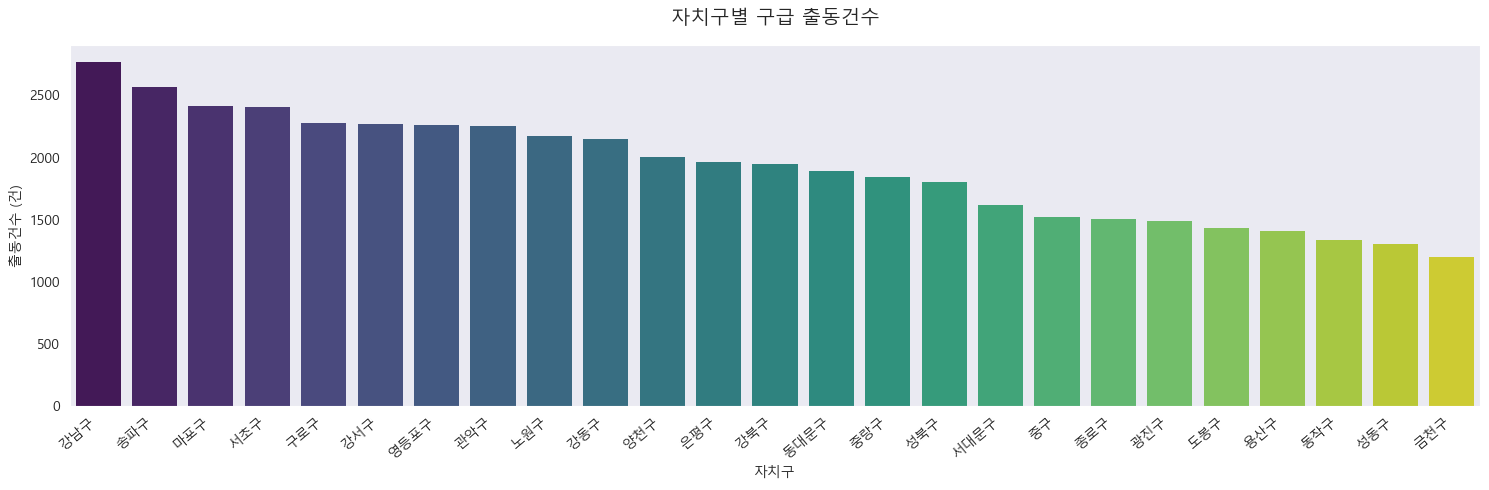

In [15]:
# 자치구별 출동건수 막대그래프
fig, ax = plt.subplots(figsize=(15, 5))

sns.barplot(
    data=fire_df, 
    x='District', 
    y='y', 
    hue='District',     
    dodge=False,      
    palette='viridis', 
    edgecolor='none', 
    linewidth=0, 
    ax=ax
)

ax.get_legend().remove()

ax.set_title('자치구별 구급 출동건수', fontsize=14, pad=15)
ax.set_xlabel('자치구')
ax.set_ylabel('출동건수 (건)')
plt.xticks(rotation=40, ha='right')

plt.tight_layout()
plt.show()

---
## 2. 실시간 응급실 가용병상 API 결과 — 자치구별 가용병상 현황

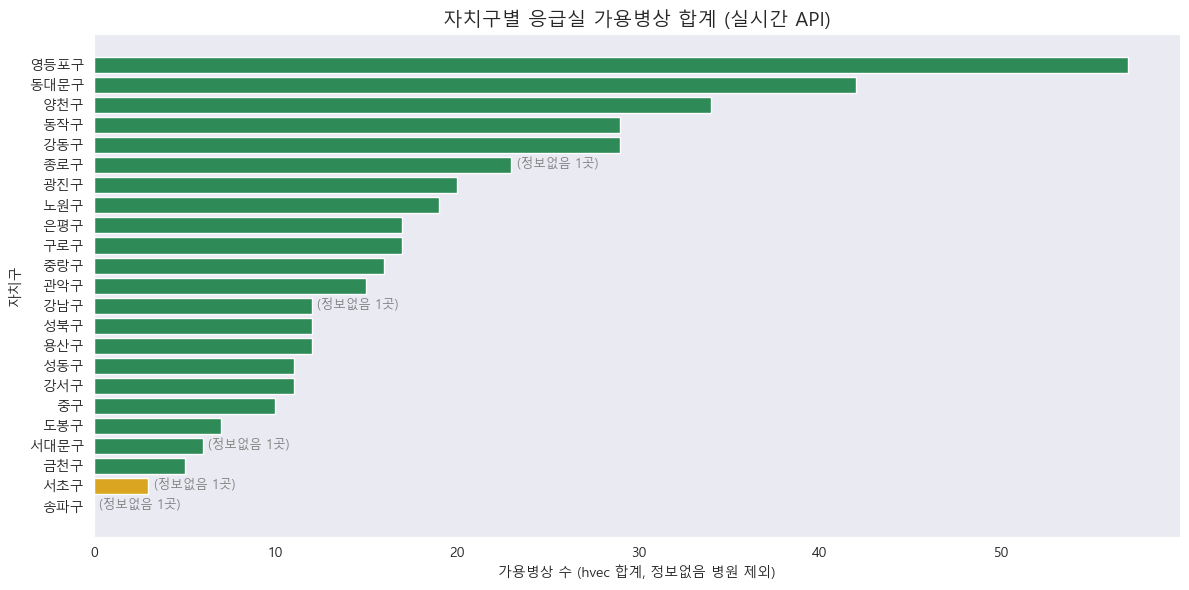

[범례] 빨강: 가용병상 0개 / 주황: 1~3개 / 초록: 4개 이상
수집 시각 범위: 2026-09-29 10:21:49.517768 ~ 2026-09-29 10:22:22.110895
병상 정보를 알 수 없는 병원 5곳 : 합계에서 제외


In [16]:
bed_path = f"{OUT_DIR}/realtime_er_beds.csv"

if os.path.exists(bed_path):
    beds_df = pd.read_csv(bed_path)

    # 병상 부족(0개) 시 음수 또는 문자로 표기 ; 결측치로 변경
    if 'Beds_Unknown' not in beds_df.columns:
        beds_df['Beds_Unknown'] = beds_df['Available_Beds'] < 0
        beds_df.loc[beds_df['Beds_Unknown'], 'Available_Beds'] = np.nan
    beds_df['Available_Beds'] = pd.to_numeric(beds_df['Available_Beds'], errors='coerce')

    # 자치구 단위로 가용병상 합계 (병원이 여러 개인 구 존재, 결측은 sum에서 자동 제외됨)
    gu_beds = beds_df.groupby('District', as_index=False).agg(
        Available_Beds=('Available_Beds', 'sum'),
        Hospital_Count=('Hospital_Name', 'nunique'),
        Unknown_Count=('Beds_Unknown', 'sum'),
        Has_Ffilled=('is_ffilled', 'any')
    ).sort_values('Available_Beds')

    # 병상 부족(0개) 여부에 따라 색상 강조
    colors = ['crimson' if v == 0 else ('goldenrod' if v <= 3 else 'seagreen')
              for v in gu_beds['Available_Beds']]

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(gu_beds['District'], gu_beds['Available_Beds'], color=colors)
    ax.set_title('자치구별 응급실 가용병상 합계 (실시간 API)', fontsize=14)
    ax.set_xlabel('가용병상 수 (hvec 합계, 정보없음 병원 제외)')
    ax.set_ylabel('자치구')

    # ffill 되었거나 정보없음 병원이 있는 구는 라벨에 표시
    for i, (ffilled, unk) in enumerate(zip(gu_beds['Has_Ffilled'], gu_beds['Unknown_Count'])):
        note = []
        if ffilled:
            note.append('직전값 대체')
        if unk > 0:
            note.append(f'정보없음 {unk}곳')
        if note:
            ax.text(gu_beds['Available_Beds'].iloc[i] + 0.3, i, '(' + ', '.join(note) + ')',
                    va='center', fontsize=9, color='gray')

    plt.tight_layout()
    plt.show()

    print("[범례] 빨강: 가용병상 0개 / 주황: 1~3개 / 초록: 4개 이상")
    print(f"수집 시각 범위: {beds_df['collected_at'].min()} ~ {beds_df['collected_at'].max()}")
    total_unknown = int(beds_df['Beds_Unknown'].sum())
    if total_unknown:
        print(f"병상 정보를 알 수 없는 병원 {total_unknown}곳 : 합계에서 제외")
else:
    print("[안내] realtime_er_beds.csv가 아직 없습니다.")


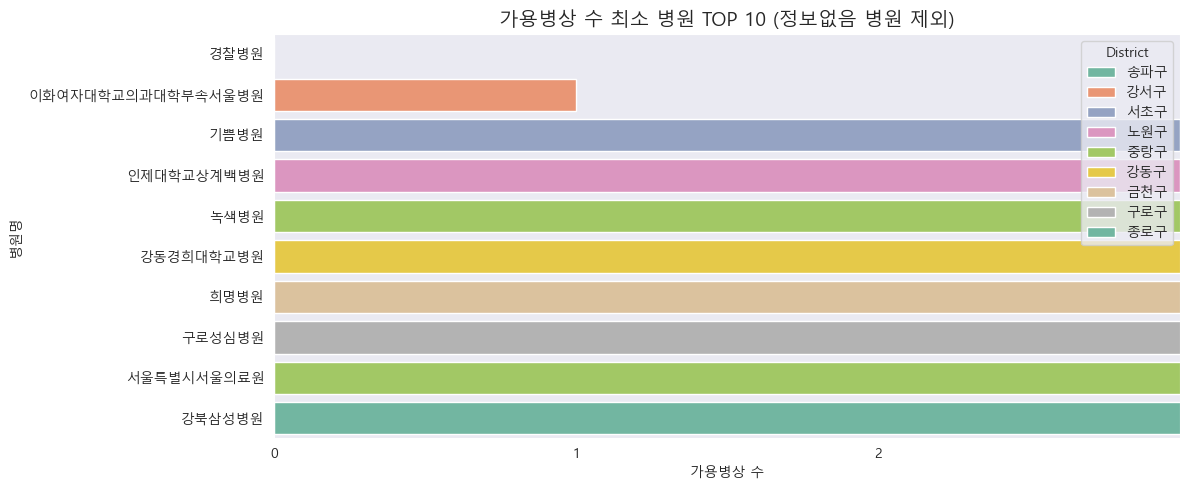

--- 병상 정보를 알 수 없는 병원 5곳 ---


,District,Hospital_Name
1,강남구,삼성서울병원
23,서대문구,연세대학교의과대학세브란스병원
25,서초구,학교법인가톨릭학원가톨릭대학교서울성모병원
29,송파구,재단법인아산사회복지재단 서울아산병원
43,종로구,서울대학교병원


In [17]:
# 병원 단위 상세 (가용병상 적은 순 TOP 10, 정보없음 병원 제외)
if os.path.exists(bed_path):
    known_beds = beds_df[~beds_df['Beds_Unknown']].copy()
    low_beds = known_beds.sort_values('Available_Beds').head(10)

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(data=low_beds, x='Available_Beds', y='Hospital_Name', hue='District',
                dodge=False, palette='Set2', ax=ax)
    
    ax.set_xlim(0, 3)
    ax.set_xticks(range(0, 3))
    ax.set_title('가용병상 수 최소 병원 TOP 10 (정보없음 병원 제외)', fontsize=14)
    ax.set_xlabel('가용병상 수')
    ax.set_ylabel('병원명')
    plt.tight_layout()
    plt.show()

    if beds_df['Beds_Unknown'].any():
        unknown_hospitals = beds_df[beds_df['Beds_Unknown']][['District', 'Hospital_Name']]
        print(f"--- 병상 정보를 알 수 없는 병원 {len(unknown_hospitals)}곳 ---")
        display(unknown_hospitals)
